# Feature Selection Using Filter Methods

This notebook demonstrates filter-based feature selection using:
- Variance Threshold
- Correlation Coefficient
- Chi-Square Test
- ANOVA F-test
- Mutual Information

**Note:** The uploaded sample dataset is very small. Therefore, Chi-Square, ANOVA, and Mutual Information may not produce reliable conclusions. They are included to demonstrate the methodology.


In [17]:
# Import the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import (
    VarianceThreshold,
    SelectKBest,
    chi2,
    f_classif,
    mutual_info_classif
)
from sklearn.preprocessing import MinMaxScaler


## 1. Load the Dataset

The CSV file is loaded into a pandas DataFrame. We inspect its shape, first rows, data types, and missing values.


In [18]:
# Load the dataset
df = pd.read_csv("D:\BDA_0024\AML_LAB\Datasets\data-1.csv")

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())


Dataset Shape: (5, 4)

First 5 rows:


,offer,Age,online payment,items
0,1,35,0,5
1,1,26,0,4
2,1,41,0,9
3,1,34,0,10
4,1,38,0,3



Data Types:
offer             int64
Age               int64
online payment    int64
items             int64
dtype: object

Missing Values:
offer             0
Age               0
online payment    0
items             0
dtype: int64


## 2. Separate Features and Target

For this demonstration, `offer` is treated as the target variable. Change `target_column` if another column is the actual target in your project.

`X` contains input features and `y` contains the target.


In [19]:
# Define the target column
target_column = "offer"

# Separate input features and target
X = df.drop(columns=[target_column])
y = df[target_column]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(target_column)

print("\nTarget value counts:")
print(y.value_counts())


Features:
['Age', 'online payment', 'items']

Target:
offer

Target value counts:
offer
1    5
Name: count, dtype: int64


## 3. Descriptive Statistics

Descriptive statistics provide an initial understanding of the numerical variables.


In [20]:
display(df.describe())


,offer,Age,online payment,items
count,5.0,5.000000,5.0,5.000000
mean,1.0,34.800000,0.0,6.200000
std,0.0,5.630275,0.0,3.114482
min,1.0,26.000000,0.0,3.000000
25%,1.0,34.000000,0.0,4.000000
50%,1.0,35.000000,0.0,5.000000
75%,1.0,38.000000,0.0,9.000000
max,1.0,41.000000,0.0,10.000000


## 4. Filter Method 1 — Variance Threshold

Variance Threshold removes features that have no variation or very little variation. A feature with zero variance has the same value for every observation and cannot distinguish observations.

Here, a threshold of `0.0` removes only features with exactly zero variance.


In [21]:
# Create the Variance Threshold selector
variance_selector = VarianceThreshold(threshold=0.0)

# Fit the selector
variance_selector.fit(X)

# Identify selected and removed features
selected_mask = variance_selector.get_support()
variance_selected = X.columns[selected_mask].tolist()
variance_removed = X.columns[~selected_mask].tolist()

print("Features selected by Variance Threshold:")
print(variance_selected)

print("\nFeatures removed because their variance is zero:")
print(variance_removed)


Features selected by Variance Threshold:
['Age', 'items']

Features removed because their variance is zero:
['online payment']


Feature Variance:


,Variance
Age,31.7
online payment,0.0
items,9.7


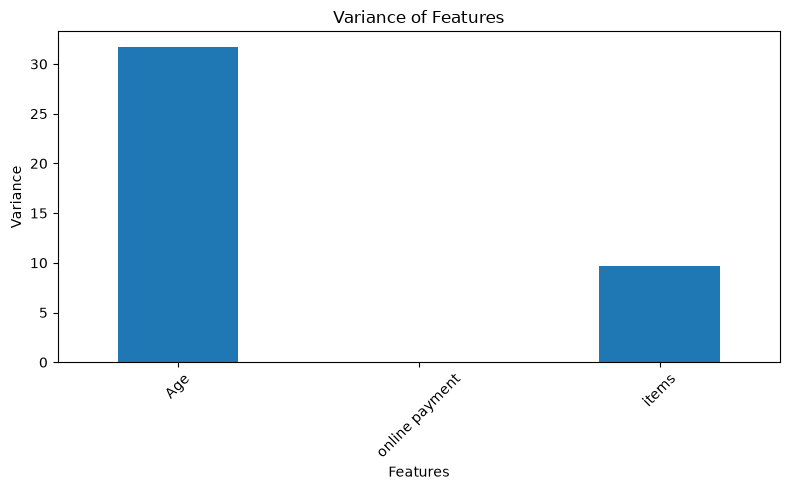

In [22]:
# Calculate and display the variance of each feature
feature_variance = X.var()

print("Feature Variance:")
display(feature_variance.to_frame(name="Variance"))

# Visualize feature variances
plt.figure(figsize=(8, 5))
feature_variance.plot(kind="bar")
plt.title("Variance of Features")
plt.xlabel("Features")
plt.ylabel("Variance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 5. Filter Method 2 — Correlation Coefficient

Correlation measures the strength and direction of a linear relationship between numerical variables. Features with very high correlation with each other may contain redundant information.


Correlation Matrix:


,Age,online payment,items
Age,1.00000,NaN,0.33076
online payment,NaN,NaN,NaN
items,0.33076,NaN,1.00000


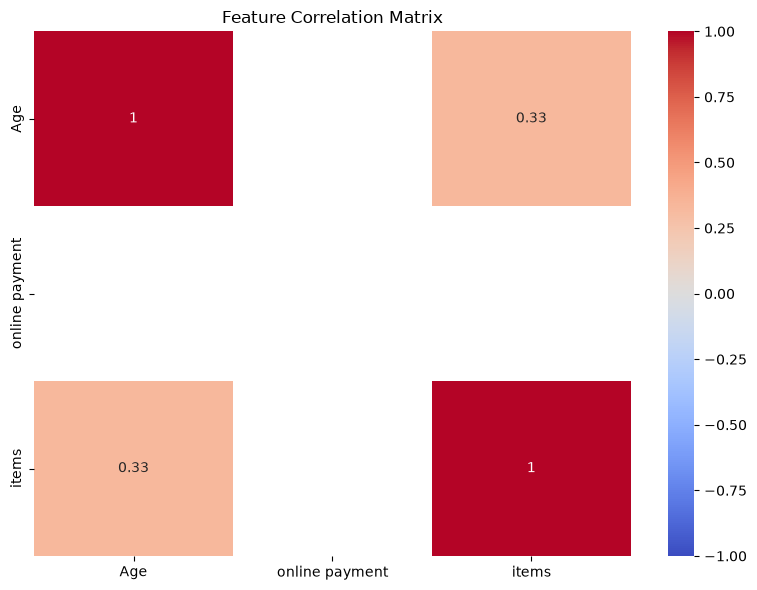

In [23]:
# Calculate the correlation matrix
correlation_matrix = X.corr(numeric_only=True)

print("Correlation Matrix:")
display(correlation_matrix)

# Plot the correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()


In [24]:
# Identify features involved in high correlation
feature_corr = X.corr(numeric_only=True).abs()

upper_triangle = feature_corr.where(
    np.triu(np.ones(feature_corr.shape), k=1).astype(bool)
)

# Example threshold: absolute correlation > 0.80
high_correlation = [
    column
    for column in upper_triangle.columns
    if any(upper_triangle[column] > 0.80)
]

print("Features involved in correlation greater than 0.80:")
print(high_correlation)


Features involved in correlation greater than 0.80:
[]


## 6. Filter Method 3 — Chi-Square Test

The Chi-Square test evaluates the association between a feature and a categorical target. The input values supplied to `chi2` must be non-negative.

**Important:** If the target contains only one class, Chi-Square feature selection is not statistically meaningful. The code checks the number of target classes before running the test.


In [25]:
# Run Chi-Square only when the target has at least two classes
if y.nunique() >= 2:
    scaler = MinMaxScaler()
    X_non_negative = scaler.fit_transform(X)

    chi_selector = SelectKBest(score_func=chi2, k="all")
    chi_selector.fit(X_non_negative, y)

    chi2_results = pd.DataFrame({
        "Feature": X.columns,
        "Chi2 Score": chi_selector.scores_,
        "P-Value": chi_selector.pvalues_
    }).sort_values("Chi2 Score", ascending=False)

    display(chi2_results)
else:
    print("Chi-Square was not applied.")
    print("Reason: The target contains fewer than two classes.")


Chi-Square was not applied.
Reason: The target contains fewer than two classes.


## 7. Filter Method 4 — ANOVA F-Test

ANOVA F-test evaluates whether the mean of a numerical feature differs significantly across classes of a categorical target.

A larger F-score indicates larger between-group variation relative to within-group variation.

**Important:** ANOVA classification requires at least two target classes.


In [26]:
# Run ANOVA only when the target contains at least two classes
if y.nunique() >= 2:
    anova_selector = SelectKBest(score_func=f_classif, k="all")
    anova_selector.fit(X, y)

    anova_results = pd.DataFrame({
        "Feature": X.columns,
        "ANOVA F-Score": anova_selector.scores_,
        "P-Value": anova_selector.pvalues_
    }).sort_values("ANOVA F-Score", ascending=False)

    display(anova_results)
else:
    print("ANOVA F-test was not applied.")
    print("Reason: The target contains fewer than two classes.")


ANOVA F-test was not applied.
Reason: The target contains fewer than two classes.


## 8. Filter Method 5 — Mutual Information

Mutual Information measures the amount of information a feature provides about the target. It can identify dependencies that are not necessarily linear.

A higher score indicates greater dependency between the feature and target.

**Important:** Classification-based Mutual Information is meaningful only when the target contains multiple classes.


In [27]:
# Run Mutual Information only when the target contains at least two classes
if y.nunique() >= 2:
    mi_scores = mutual_info_classif(X, y, random_state=42)

    mi_results = pd.DataFrame({
        "Feature": X.columns,
        "Mutual Information": mi_scores
    }).sort_values("Mutual Information", ascending=False)

    display(mi_results)

    # Visualize Mutual Information scores
    plt.figure(figsize=(8, 5))
    plt.bar(mi_results["Feature"], mi_results["Mutual Information"])
    plt.xlabel("Features")
    plt.ylabel("Mutual Information")
    plt.title("Mutual Information Feature Scores")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("Mutual Information was not applied.")
    print("Reason: The target contains fewer than two classes.")


Mutual Information was not applied.
Reason: The target contains fewer than two classes.


## 9. Final Feature Selection

Features removed by the Variance Threshold method are excluded from the final feature matrix.

The final selected feature matrix can be passed to a machine-learning model.


In [28]:
# Keep features that passed the variance filter
X_selected = X[variance_selected]

print("Final features after Variance Threshold:")
print(X_selected.columns.tolist())

print("\nFinal selected feature dataset:")
display(X_selected)


Final features after Variance Threshold:
['Age', 'items']

Final selected feature dataset:


,Age,items
0,35,5
1,26,4
2,41,9
3,34,10
4,38,3


## 10. Summary

### Filter Methods Used

1. **Variance Threshold** — removes constant or low-variance features.
2. **Correlation Coefficient** — identifies highly correlated and potentially redundant features.
3. **Chi-Square Test** — evaluates association between features and a categorical target.
4. **ANOVA F-Test** — evaluates differences in numerical feature means across target classes.
5. **Mutual Information** — measures how much information a feature provides about the target.

### Important Observation

The uploaded sample dataset contains only five observations and the demonstrated `offer` target has a single class. Therefore, the classification-based statistical methods cannot provide reliable feature rankings for this sample. A sufficiently large dataset with a meaningful target containing multiple classes should be used for final feature-selection analysis.
